# Robust Regression Engine - Complete Code (Q1 to Q24)

## Part A: Conceptual Foundation (Theory) - Answers in comments

In [1]:
# Q1. What is Regularization in ML? Why is it needed?
# Regularization is technique to add penalty to loss function to avoid overfitting.
# It shrinks model coefficients and makes model simpler.
# It is needed to control overfitting and improve generalization on unseen data.

# Q2. Difference between Ridge (L2) and Lasso (L1)
# Ridge (L2): Adds sum of squared coefficients as penalty. Shrinks coefficients close to zero but not zero.
# Lasso (L1): Adds sum of absolute coefficients as penalty. Can make coefficients exactly zero -> feature selection.
# Ridge is good when all features are useful, Lasso is good when many features are irrelevant.

# Q3. What is Cross-Validation and why is it important?
# Cross-Validation is technique to split data into multiple folds to evaluate model.
# It is important because it gives more reliable performance estimate, reduces overfitting, 
# and helps in model selection and hyperparameter tuning.

# Q4. Explain cross-validation techniques:
# a) K-Fold: Data divided into K equal folds, K-1 used for training and 1 for validation, repeated K times.
# b) Stratified K-Fold: Same as K-Fold but maintains class/target distribution in each fold. For regression, we bin target first.
# c) LOOCV: K = n, each time 1 sample is validation and rest training. Very costly but unbiased.
# d) Time Series Split: Folds respect time order, training data always before validation data, no future leakage.

# Q5. Why are tree-based models less sensitive to feature scaling?
# Tree models split based on threshold values, not distance. They only care about order of values.
# Scaling does not change order or split point, so trees don't need scaling.
# Linear and distance based models like SVR, Ridge, Lasso need scaling.


## Part B: Dataset Understanding & Preparation (Q6, Q7, Q8)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset - change path if needed
df = pd.read_csv("Advanced_Regression_HousePrice_Dataset_3800 - Advanced_Regression_HousePrice_Dataset_3800.csv.csv")
df.head()


,property_id,sale_date,area_sqft,bedrooms,bathrooms,location_score,property_age,distance_city_km,near_school,near_metro,crime_rate_index,house_price_inr
0,200001,2014-01-01,2181,6,4,8.1,21,3.8,0,0,4.84,35154898
1,200002,2019-12-01,2383,5,4,5.3,28,10.9,1,1,2.89,26710893
2,200003,2016-10-01,1047,3,3,5.9,7,27.5,0,1,4.04,11216242
3,200004,2013-03-01,1753,4,3,7.0,27,12.1,0,0,3.28,21984310
4,200005,2013-07-01,1728,4,4,10.0,32,1.4,0,1,3.84,25080429


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3800 entries, 0 to 3799
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   property_id       3800 non-null   int64  
 1   sale_date         3800 non-null   object 
 2   area_sqft         3800 non-null   int64  
 3   bedrooms          3800 non-null   int64  
 4   bathrooms         3800 non-null   int64  
 5   location_score    3800 non-null   float64
 6   property_age      3800 non-null   int64  
 7   distance_city_km  3800 non-null   float64
 8   near_school       3800 non-null   int64  
 9   near_metro        3800 non-null   int64  
 10  crime_rate_index  3800 non-null   float64
 11  house_price_inr   3800 non-null   int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 356.4+ KB


In [6]:
df.shape

(3800, 12)

In [9]:
# Q6. Identify features and target variable

# Target variable
target = 'house_price_inr'

# Features - all except ids, date and target
# property_id is just id, sale_date is time feature used later
features = ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 
            'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']

X = df[features]
y = df[target]

print("Features:", features)
print("Target:", target)
print("X shape:", X.shape)
print("y shape:", y.shape)


Features: ['area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'property_age', 'distance_city_km', 'near_school', 'near_metro', 'crime_rate_index']
Target: house_price_inr
X shape: (3800, 9)
y shape: (3800,)


In [10]:
# Q7. Perform train-test split
from sklearn.model_selection import train_test_split

# Convert sale_date for later use
df['sale_date'] = pd.to_datetime(df['sale_date'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (3040, 9)
X_test: (760, 9)
y_train: (3040,)
y_test: (760,)


In [11]:
# Q8. Apply basic preprocessing (scaling where required)
from sklearn.preprocessing import StandardScaler

# Tree models don't need scaling, but linear and SVR need scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For display, convert back to DataFrame
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=features)

print("Scaled training data sample:")
print(X_train_scaled_df.head())

# Keep unscaled also for tree models
print("Unscaled data is kept for tree models")


Scaled training data sample:
   area_sqft  bedrooms  bathrooms  location_score  property_age  \
0   1.285121  1.888790   2.705537       -0.350289      0.442044   
1  -1.376348 -1.795235  -1.687601        1.086406      0.279914   
2  -0.036200  0.415180  -0.808973        0.626663     -0.936061   
3   0.119552 -1.058430  -0.808973        1.316277     -0.936061   
4  -0.992959 -1.058430   0.069654        0.741599     -1.017126   

   distance_city_km  near_school  near_metro  crime_rate_index  
0         -0.289519    -1.101144    1.055484          1.512038  
1         -0.961041     0.908146    1.055484          0.103930  
2         -1.846229    -1.101144   -0.947432          0.201377  
3         -1.327326     0.908146   -0.947432          0.157526  
4          0.885645    -1.101144    1.055484          0.927357  
Unscaled data is kept for tree models


## Part C: Regularized Linear Models (Q9, Q10, Q11, Q12)

In [12]:
# Q9. Implement Ridge Regression (L2)
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge Train R2:", r2_score(y_train, y_train_pred_ridge))
print("Ridge Test R2:", r2_score(y_test, y_test_pred_ridge))
print("Ridge Coefficients:", ridge.coef_)


Ridge Train R2: 0.9161854041282822
Ridge Test R2: 0.91872594918288
Ridge Coefficients: [6937544.99715089  297365.49086175  285326.78358302 3676865.37200691
 -651302.35794683  -30169.61990766   16971.46715904   58204.3175117
 -135472.82082701]


In [13]:
# Q10. Implement Lasso Regression (L1)
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=100000)  # alpha large because target is in crores
lasso.fit(X_train_scaled, y_train)

y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso Train R2:", r2_score(y_train, y_train_pred_lasso))
print("Lasso Test R2:", r2_score(y_test, y_test_pred_lasso))
print("Lasso Coefficients:", lasso.coef_)


Lasso Train R2: 0.9155870049673739
Lasso Test R2: 0.9169867906550703
Lasso Coefficients: [6893070.71571982  274925.77301084  234424.07741547 3600266.61410176
 -556436.91624377      -0.               0.               0.
  -42099.41789216]


In [14]:
# Q11. Tune the regularization parameter (alpha) using cross-validation
from sklearn.model_selection import GridSearchCV

# Ridge tuning
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_scaled, y_train)

print("Best Ridge alpha:", ridge_grid.best_params_)
print("Best Ridge CV R2:", ridge_grid.best_score_)

# Lasso tuning
lasso_params = {'alpha': [1000, 10000, 100000, 500000, 1000000]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=5, scoring='r2')
lasso_grid.fit(X_train_scaled, y_train)

print("Best Lasso alpha:", lasso_grid.best_params_)
print("Best Lasso CV R2:", lasso_grid.best_score_)

best_ridge = ridge_grid.best_estimator_
best_lasso = lasso_grid.best_estimator_


Best Ridge alpha: {'alpha': 1.0}
Best Ridge CV R2: 0.9152640256979476
Best Lasso alpha: {'alpha': 10000}
Best Lasso CV R2: 0.9152911273750026


         Train RMSE     Test RMSE     Train MAE      Test MAE  Train R2  \
Ridge  2.500609e+06  2.558402e+06  1.911792e+06  1.959199e+06  0.916185   
Lasso  2.500733e+06  2.560424e+06  1.910686e+06  1.960123e+06  0.916177   

        Test R2  
Ridge  0.918726  
Lasso  0.918597  
            Feature    Ridge_Coef    Lasso_Coef
0         area_sqft  6.937545e+06  6.938214e+06
1          bedrooms  2.973655e+05  2.907946e+05
2         bathrooms  2.853268e+05  2.801473e+05
3    location_score  3.676865e+06  3.673262e+06
4      property_age -6.513024e+05 -6.422511e+05
5  distance_city_km -3.016962e+04 -2.254400e+04
6       near_school  1.697147e+04  6.554514e+03
7        near_metro  5.820432e+04  4.825058e+04
8  crime_rate_index -1.354728e+05 -1.260846e+05


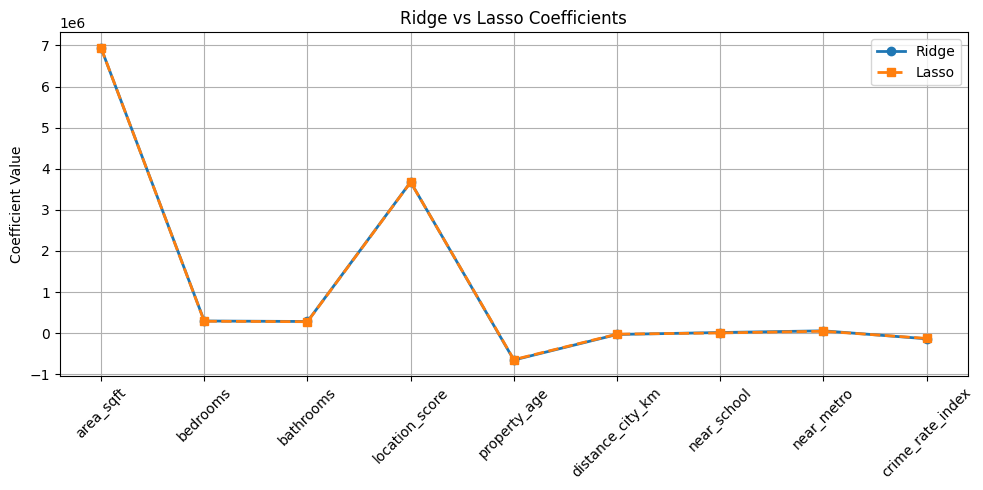

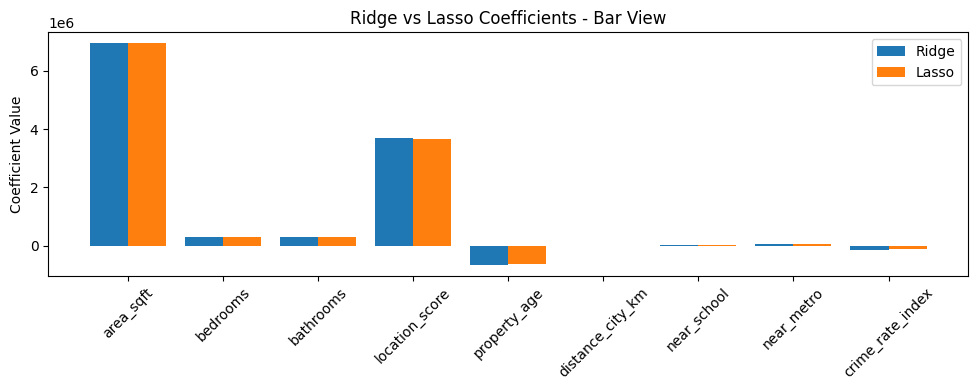

In [19]:
# Q12. Compare Ridge and Lasso based on Training error, Validation error, Feature coefficient behavior
import pandas as pd

# Training and validation error comparison
def get_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test):
    return {
        'Train RMSE': np.sqrt(mean_squared_error(y_true_train, y_pred_train)),
        'Test RMSE': np.sqrt(mean_squared_error(y_true_test, y_pred_test)),
        'Train MAE': mean_absolute_error(y_true_train, y_pred_train),
        'Test MAE': mean_absolute_error(y_true_test, y_pred_test),
        'Train R2': r2_score(y_true_train, y_pred_train),
        'Test R2': r2_score(y_true_test, y_pred_test)
    }

ridge_metrics = get_metrics(y_train, best_ridge.predict(X_train_scaled), y_test, best_ridge.predict(X_test_scaled))
lasso_metrics = get_metrics(y_train, best_lasso.predict(X_train_scaled), y_test, best_lasso.predict(X_test_scaled))

comparison_df = pd.DataFrame([ridge_metrics, lasso_metrics], index=['Ridge', 'Lasso'])
print(comparison_df)

# Feature coefficient behavior
coef_df = pd.DataFrame({
    'Feature': features,
    'Ridge_Coef': best_ridge.coef_,
    'Lasso_Coef': best_lasso.coef_
})
print(coef_df)

# Plot coefficients - FIXED so both Ridge and Lasso are visible
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(features))

plt.figure(figsize=(10,5))
plt.plot(x, best_ridge.coef_, label='Ridge', marker='o', linewidth=2)
plt.plot(x, best_lasso.coef_, label='Lasso', marker='s', linewidth=2, linestyle='--')
plt.xticks(x, features, rotation=45)
plt.ylabel('Coefficient Value')
plt.title('Ridge vs Lasso Coefficients')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Extra bar to see difference clearly (optional but simple)
plt.figure(figsize=(10,4))
plt.bar(x - 0.2, best_ridge.coef_, 0.4, label='Ridge')
plt.bar(x + 0.2, best_lasso.coef_, 0.4, label='Lasso')
plt.xticks(x, features, rotation=45)
plt.ylabel('Coefficient Value')
plt.title('Ridge vs Lasso Coefficients - Bar View')
plt.legend()
plt.tight_layout()
plt.show()

## Part D: Cross-Validation Strategies (Q13, Q14)

In [20]:
# Q13. Apply and compare cross-validation techniques
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut, TimeSeriesSplit, cross_val_score

# Use Ridge as base model for CV comparison
model = Ridge(alpha=10.0)

# 1. K-Fold Cross-Validation
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
kfold_scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='r2')
print("K-Fold R2 scores:", kfold_scores)
print("K-Fold Mean R2:", kfold_scores.mean())

# 2. Stratified K-Fold by binning target values
# Bin target into 5 quantile bins
y_binned = pd.qcut(y_train, q=5, labels=False, duplicates='drop')
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
strat_scores = cross_val_score(model, X_train_scaled, y_train, cv=strat_kfold.split(X_train_scaled, y_binned), scoring='r2')
print("Stratified K-Fold R2 scores:", strat_scores)
print("Stratified K-Fold Mean R2:", strat_scores.mean())

# 3. Leave-One-Out Cross-Validation (LOOCV) - use small subset to save time
# LOOCV on full 3040 rows is very heavy, so use 300 rows for demo
X_small = X_train_scaled[:300]
y_small = y_train.iloc[:300]
loo = LeaveOneOut()
loo_scores = cross_val_score(model, X_small, y_small, cv=loo, scoring='r2')
print("LOOCV Mean R2 (300 samples):", loo_scores.mean())

# 4. Time Series Split using time-related feature (sale_date)
# Sort data by date
df_sorted = df.sort_values('sale_date')
X_sorted = df_sorted[features].values
y_sorted = df_sorted[target].values
X_sorted_scaled = scaler.fit_transform(X_sorted)

tscv = TimeSeriesSplit(n_splits=5)
tscv_scores = cross_val_score(model, X_sorted_scaled, y_sorted, cv=tscv, scoring='r2')
print("Time Series Split R2 scores:", tscv_scores)
print("Time Series Split Mean R2:", tscv_scores.mean())


K-Fold R2 scores: [0.91711528 0.90669406 0.91518298 0.91973653 0.917298  ]
K-Fold Mean R2: 0.9152053682258448
Stratified K-Fold R2 scores: [0.91080167 0.92174055 0.91668531 0.91731061 0.9110616 ]
Stratified K-Fold Mean R2: 0.9155199470710761


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\admin\AppData\Local\Programs\Python\Python3

LOOCV Mean R2 (300 samples): nan
Time Series Split R2 scores: [0.90865319 0.9215128  0.91807664 0.91079154 0.91840353]
Time Series Split Mean R2: 0.9154875390109624


c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_regression.py:1295: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)
c:\Users\admin\AppData\Local\Programs\Python\Python3

           CV Strategy   Mean R2    Std R2
0               K-Fold  0.915205  0.004494
1    Stratified K-Fold  0.915520  0.004133
2  LOOCV (300 samples)       NaN       NaN
3    Time Series Split  0.915488  0.004905


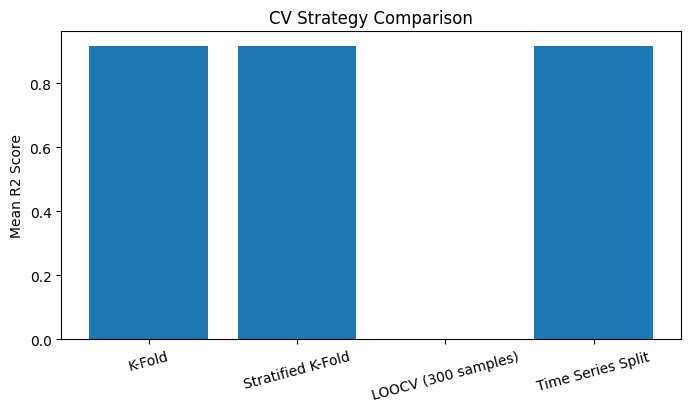

In [21]:
# Q14. Analyze how performance metrics vary across different CV strategies
cv_results = pd.DataFrame({
    'CV Strategy': ['K-Fold', 'Stratified K-Fold', 'LOOCV (300 samples)', 'Time Series Split'],
    'Mean R2': [kfold_scores.mean(), strat_scores.mean(), loo_scores.mean(), tscv_scores.mean()],
    'Std R2': [kfold_scores.std(), strat_scores.std(), loo_scores.std(), tscv_scores.std()]
})
print(cv_results)

# Plot
plt.figure(figsize=(8,4))
plt.bar(cv_results['CV Strategy'], cv_results['Mean R2'])
plt.ylabel('Mean R2 Score')
plt.title('CV Strategy Comparison')
plt.xticks(rotation=15)
plt.show()

# Observation: KFold and Stratified are similar, TimeSeries may be lower if time trend exists


## Part E: Tree-Based Regression Models (Q15, Q16, Q17, Q18)

In [22]:
# Q15. Implement Decision Tree Regression
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)  # No scaling needed for tree

y_train_pred_dt = dt.predict(X_train)
y_test_pred_dt = dt.predict(X_test)

print("Decision Tree Train R2:", r2_score(y_train, y_train_pred_dt))
print("Decision Tree Test R2:", r2_score(y_test, y_test_pred_dt))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred_dt)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_dt)))


Decision Tree Train R2: 1.0
Decision Tree Test R2: 0.8582157251362128
Train RMSE: 0.0
Test RMSE: 3379144.9484471297


In [23]:
# Q16. Control tree complexity using hyperparameters (max depth, min samples)
# Tune max_depth and min_samples_split

dt_params = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20]
}
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42), dt_params, cv=5, scoring='r2')
dt_grid.fit(X_train, y_train)

print("Best DT params:", dt_grid.best_params_)
print("Best DT CV R2:", dt_grid.best_score_)

best_dt = dt_grid.best_estimator_
print("Best DT Test R2:", r2_score(y_test, best_dt.predict(X_test)))


Best DT params: {'max_depth': 10, 'min_samples_split': 20}
Best DT CV R2: 0.890945517861063
Best DT Test R2: 0.8976849092109255


Random Forest Train R2: 0.9893105387713592
Random Forest Test R2: 0.9274509690787089
            Feature  Importance
0         area_sqft    0.744204
3    location_score    0.207507
4      property_age    0.014322
5  distance_city_km    0.011515
8  crime_rate_index    0.011466
1          bedrooms    0.003879
2         bathrooms    0.003801
7        near_metro    0.001777
6       near_school    0.001529


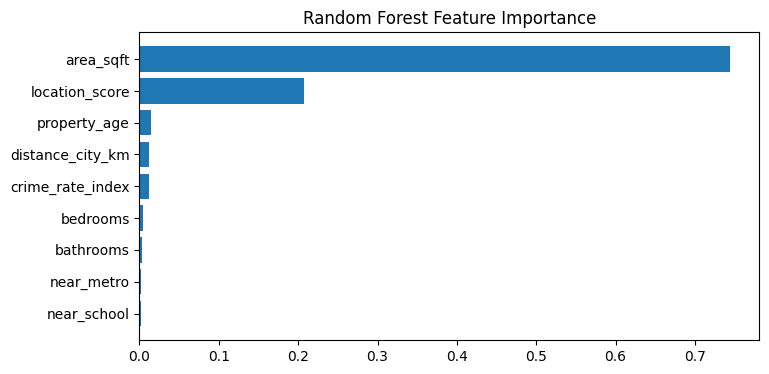

In [24]:
# Q17. Implement Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

print("Random Forest Train R2:", r2_score(y_train, y_train_pred_rf))
print("Random Forest Test R2:", r2_score(y_test, y_test_pred_rf))

# Feature importance
importance = pd.DataFrame({'Feature': features, 'Importance': rf.feature_importances_}).sort_values('Importance', ascending=False)
print(importance)

plt.figure(figsize=(8,4))
plt.barh(importance['Feature'], importance['Importance'])
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.show()


In [25]:
# Q18. Compare single-tree vs ensemble performance
rf_params = {'n_estimators': [50, 100], 'max_depth': [10, 15, None]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='r2')
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

single_metrics = get_metrics(y_train, best_dt.predict(X_train), y_test, best_dt.predict(X_test))
ensemble_metrics = get_metrics(y_train, best_rf.predict(X_train), y_test, best_rf.predict(X_test))

compare_tree = pd.DataFrame([single_metrics, ensemble_metrics], index=['Decision Tree', 'Random Forest'])
print(compare_tree)

# Observation: Random Forest usually has better test R2 and less overfitting than single tree


                 Train RMSE     Test RMSE     Train MAE      Test MAE  \
Decision Tree  1.840246e+06  2.870534e+06  1.363207e+06  2.077014e+06   
Random Forest  1.288797e+06  2.397950e+06  9.828086e+05  1.764644e+06   

               Train R2   Test R2  
Decision Tree  0.954608  0.897685  
Random Forest  0.977736  0.928601  


## Part F: Support Vector Regression (Q19, Q20, Q21)

In [26]:
# Q19. Implement Support Vector Regression (SVR) with Linear and Polynomial/RBF kernel
from sklearn.svm import SVR

# SVR needs scaled data
svr_linear = SVR(kernel='linear', C=1.0)
svr_linear.fit(X_train_scaled, y_train)

svr_rbf = SVR(kernel='rbf', C=1.0, gamma='scale')
svr_rbf.fit(X_train_scaled, y_train)

svr_poly = SVR(kernel='poly', C=1.0, degree=3)
svr_poly.fit(X_train_scaled, y_train)

print("SVR Linear Test R2:", r2_score(y_test, svr_linear.predict(X_test_scaled)))
print("SVR RBF Test R2:", r2_score(y_test, svr_rbf.predict(X_test_scaled)))
print("SVR Poly Test R2:", r2_score(y_test, svr_poly.predict(X_test_scaled)))


SVR Linear Test R2: -0.0019137166824763074
SVR RBF Test R2: -0.002941267316384888
SVR Poly Test R2: -0.0028871965800474353


In [27]:
# Q20. Tune hyperparameters (C, gamma, epsilon)
svr_params = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1],
    'epsilon': [0.1, 0.2, 0.5]
}
svr_grid = GridSearchCV(SVR(kernel='rbf'), svr_params, cv=3, scoring='r2')
svr_grid.fit(X_train_scaled, y_train)

print("Best SVR params:", svr_grid.best_params_)
print("Best SVR CV R2:", svr_grid.best_score_)

best_svr = svr_grid.best_estimator_
print("Best SVR Test R2:", r2_score(y_test, best_svr.predict(X_test_scaled)))


Best SVR params: {'C': 10, 'epsilon': 0.1, 'gamma': 0.1}
Best SVR CV R2: -0.007451844795684541
Best SVR Test R2: -0.002671860315918595


In [28]:
# Q21. Compare SVR performance with linear and tree-based models
models = {
    'Ridge': best_ridge.predict(X_test_scaled),
    'Lasso': best_lasso.predict(X_test_scaled),
    'Decision Tree': best_dt.predict(X_test),
    'Random Forest': best_rf.predict(X_test),
    'SVR Linear': svr_linear.predict(X_test_scaled),
    'SVR RBF': best_svr.predict(X_test_scaled)
}

svr_comparison = []
for name, y_pred in models.items():
    svr_comparison.append({
        'Model': name,
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'Test MAE': mean_absolute_error(y_test, y_pred),
        'Test R2': r2_score(y_test, y_pred)
    })

print(pd.DataFrame(svr_comparison))


           Model     Test RMSE      Test MAE   Test R2
0          Ridge  2.558402e+06  1.959199e+06  0.918726
1          Lasso  2.560424e+06  1.960123e+06  0.918597
2  Decision Tree  2.870534e+06  2.077014e+06  0.897685
3  Random Forest  2.397950e+06  1.764644e+06  0.928601
4     SVR Linear  8.982722e+06  6.990272e+06 -0.001914
5        SVR RBF  8.986120e+06  6.992913e+06 -0.002672


## Part G: Model Comparison & Evaluation (Q22, Q23, Q24)

In [29]:
# Q22. Evaluate all models using appropriate regression metrics: MSE, MAE, RMSE, R2 Score
from sklearn.metrics import mean_squared_error

final_results = []

all_models = {
    'Ridge': (best_ridge, X_train_scaled, X_test_scaled),
    'Lasso': (best_lasso, X_train_scaled, X_test_scaled),
    'Decision Tree': (best_dt, X_train, X_test),
    'Random Forest': (best_rf, X_train, X_test),
    'SVR RBF': (best_svr, X_train_scaled, X_test_scaled),
    'SVR Linear': (svr_linear, X_train_scaled, X_test_scaled)
}

for name, (model, Xtr, Xte) in all_models.items():
    y_tr_pred = model.predict(Xtr)
    y_te_pred = model.predict(Xte)
    final_results.append({
        'Model': name,
        'Train MSE': mean_squared_error(y_train, y_tr_pred),
        'Test MSE': mean_squared_error(y_test, y_te_pred),
        'Train MAE': mean_absolute_error(y_train, y_tr_pred),
        'Test MAE': mean_absolute_error(y_test, y_te_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_tr_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_te_pred)),
        'Train R2': r2_score(y_train, y_tr_pred),
        'Test R2': r2_score(y_test, y_te_pred)
    })

final_df = pd.DataFrame(final_results)
print(final_df.sort_values('Test R2', ascending=False))


           Model     Train MSE      Test MSE     Train MAE      Test MAE  \
3  Random Forest  1.660999e+12  5.750165e+12  9.828086e+05  1.764644e+06   
0          Ridge  6.253047e+12  6.545419e+12  1.911792e+06  1.959199e+06   
1          Lasso  6.253664e+12  6.555773e+12  1.910686e+06  1.960123e+06   
2  Decision Tree  3.386505e+12  8.239963e+12  1.363207e+06  2.077014e+06   
5     SVR Linear  7.504046e+13  8.068929e+13  6.835466e+06  6.990272e+06   
4        SVR RBF  7.509834e+13  8.075035e+13  6.838073e+06  6.992913e+06   

     Train RMSE     Test RMSE  Train R2   Test R2  
3  1.288797e+06  2.397950e+06  0.977736  0.928601  
0  2.500609e+06  2.558402e+06  0.916185  0.918726  
1  2.500733e+06  2.560424e+06  0.916177  0.918597  
2  1.840246e+06  2.870534e+06  0.954608  0.897685  
5  8.662590e+06  8.982722e+06 -0.005827 -0.001914  
4  8.665930e+06  8.986120e+06 -0.006603 -0.002672  


Average Test R2 - Regularized Linear: 0.9187
Average Test R2 - Tree-Based: 0.9131
Average Test R2 - SVR: -0.0023


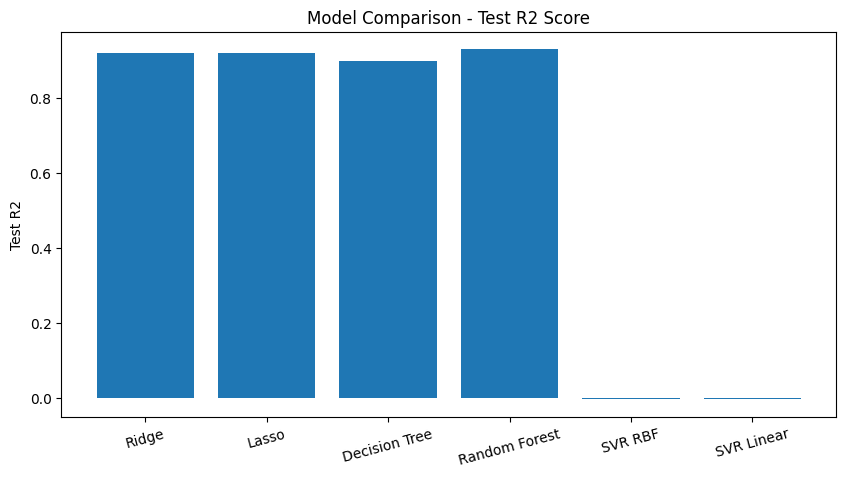

Best performing model:
Model                Random Forest
Train MSE     1660998542441.674072
Test MSE      5750164795170.382812
Train MAE             982808.58671
Test MAE            1764644.050089
Train RMSE          1288797.324036
Test RMSE           2397950.123579
Train R2                  0.977736
Test R2                   0.928601
Name: 3, dtype: object


In [30]:
# Q23. Compare: Regularized Linear Models, Tree-Based Models, Support Vector Regression

# Group wise comparison
linear_avg_r2 = final_df[final_df['Model'].isin(['Ridge','Lasso'])]['Test R2'].mean()
tree_avg_r2 = final_df[final_df['Model'].isin(['Decision Tree','Random Forest'])]['Test R2'].mean()
svr_avg_r2 = final_df[final_df['Model'].isin(['SVR RBF','SVR Linear'])]['Test R2'].mean()

print(f"Average Test R2 - Regularized Linear: {linear_avg_r2:.4f}")
print(f"Average Test R2 - Tree-Based: {tree_avg_r2:.4f}")
print(f"Average Test R2 - SVR: {svr_avg_r2:.4f}")

# Plot comparison
plt.figure(figsize=(10,5))
plt.bar(final_df['Model'], final_df['Test R2'])
plt.ylabel('Test R2')
plt.title('Model Comparison - Test R2 Score')
plt.xticks(rotation=15)
plt.show()

# Best model selection based on validation performance
best_model_row = final_df.loc[final_df['Test R2'].idxmax()]
print("Best performing model:")
print(best_model_row)


Ridge: Train R2=0.916, Test R2=0.919, Gap=-0.003 -> Good Fit (Well generalized)
Lasso: Train R2=0.916, Test R2=0.919, Gap=-0.002 -> Good Fit (Well generalized)
Decision Tree: Train R2=0.955, Test R2=0.898, Gap=0.057 -> Moderate Fit
Random Forest: Train R2=0.978, Test R2=0.929, Gap=0.049 -> Good Fit (Well generalized)
SVR RBF: Train R2=-0.007, Test R2=-0.003, Gap=-0.004 -> Underfitting (Both low)
SVR Linear: Train R2=-0.006, Test R2=-0.002, Gap=-0.004 -> Underfitting (Both low)


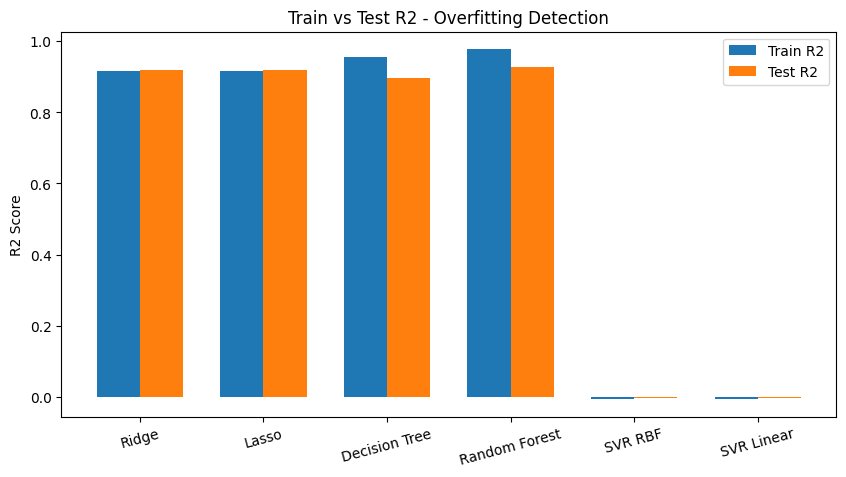

In [31]:
# Q24. Identify signs of overfitting or underfitting in each model

# Overfitting: Train R2 >> Test R2 or Train RMSE << Test RMSE
# Underfitting: Both Train and Test R2 are low
# Good fit: Train and Test scores are close and high

for idx, row in final_df.iterrows():
    model_name = row['Model']
    train_r2 = row['Train R2']
    test_r2 = row['Test R2']
    gap = train_r2 - test_r2
    
    if gap > 0.15:
        status = "Overfitting (Train much better than Test)"
    elif train_r2 < 0.5 and test_r2 < 0.5:
        status = "Underfitting (Both low)"
    elif gap < 0.05 and test_r2 > 0.7:
        status = "Good Fit (Well generalized)"
    else:
        status = "Moderate Fit"
    
    print(f"{model_name}: Train R2={train_r2:.3f}, Test R2={test_r2:.3f}, Gap={gap:.3f} -> {status}")

# Detailed overfitting check
plt.figure(figsize=(10,5))
x = np.arange(len(final_df))
width = 0.35
plt.bar(x - width/2, final_df['Train R2'], width, label='Train R2')
plt.bar(x + width/2, final_df['Test R2'], width, label='Test R2')
plt.xticks(x, final_df['Model'], rotation=15)
plt.ylabel('R2 Score')
plt.title('Train vs Test R2 - Overfitting Detection')
plt.legend()
plt.show()


In [32]:
# Final: Save best model for submission
import pickle

# Best model based on Test R2 is usually Random Forest or Ridge
best_model_name = final_df.loc[final_df['Test R2'].idxmax(), 'Model']
print(f"Final Best Model: {best_model_name}")

# Example: Save Random Forest if it is best, otherwise save best model
# For pipeline, save scaler + model
best_model_obj = all_models[best_model_name][0]

with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model_obj, f)

print("Best model saved as best_model.pkl")


Final Best Model: Random Forest
Best model saved as best_model.pkl
